In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
csv_path = "/Users/bhushanshah/Documents/llm-uncertainty-project/abstaining_results/gpqa/step_entropy/grid.csv"

In [31]:
with open(csv_path, 'r') as file:
    df = pd.read_csv(file)

df.head()

,model_name,chunk_size,delta,offset,ground_threshold,min_support_per_class,precision,recall,f1,validation_accuracy
0,deepseek-ai_DeepSeek-V3.1,50,-0.011898,0.0,1,3,0.240000,1.0,0.387097,0.00
1,deepseek-ai_DeepSeek-V3.1,50,-0.011898,0.0,2,3,0.240000,1.0,0.387097,0.00
2,deepseek-ai_DeepSeek-V3.1,50,-0.011898,0.0,3,3,0.272727,1.0,0.428571,0.12
3,deepseek-ai_DeepSeek-V3.1,50,-0.011898,0.0,4,3,0.285714,1.0,0.444444,0.16
4,deepseek-ai_DeepSeek-V3.1,50,-0.011898,0.0,5,3,0.300000,1.0,0.461538,0.20


In [32]:
#select only those rows where model_name is Qwen_Qwen3-32B
df_qwen = df[df['model_name'] == 'Qwen_Qwen3-32B']

In [33]:
df_qwen.head(1000)

,model_name,chunk_size,delta,offset,ground_threshold,min_support_per_class,precision,recall,f1,validation_accuracy
760000,Qwen_Qwen3-32B,50,-0.026343,0.000000,1,3,0.372881,1.000000,0.543210,0.016667
760001,Qwen_Qwen3-32B,50,-0.026343,0.000000,2,3,0.379310,1.000000,0.550000,0.033333
760002,Qwen_Qwen3-32B,50,-0.026343,0.000000,3,3,0.379310,1.000000,0.550000,0.033333
760003,Qwen_Qwen3-32B,50,-0.026343,0.000000,4,3,0.385965,1.000000,0.556962,0.050000
760004,Qwen_Qwen3-32B,50,-0.026343,0.000000,5,3,0.407407,1.000000,0.578947,0.100000
...,...,...,...,...,...,...,...,...,...,...
760995,Qwen_Qwen3-32B,50,-0.013577,0.144971,16,3,1.000000,0.045455,0.086957,0.633333
760996,Qwen_Qwen3-32B,50,-0.013577,0.144971,17,3,1.000000,0.045455,0.086957,0.633333
760997,Qwen_Qwen3-32B,50,-0.013577,0.144971,18,3,1.000000,0.045455,0.086957,0.633333
760998,Qwen_Qwen3-32B,50,-0.013577,0.144971,19,3,1.000000,0.045455,0.086957,0.633333


In [10]:
chunk_size=50, delta=0.05663308395133429, offset=0.0744175524170772, ground_threshold=3, min_support_per_class=3

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (4145546411.py, line 1)

In [34]:
chunk_size=50
delta=0.0566330839513342
offset=0.0744175524170772
ground_threshold=3

In [35]:
count = 0
for index, row in df_qwen.iterrows():
    if row['offset'] == 0.0744175524170772:
        count += 1
print(count)


20


In [ ]:
def print_ground_threshold_plot(df_qwen, chunk_size, delta, offset):
    df_qwen_filtered = df_qwen[
        (df_qwen['chunk_size'] == chunk_size) &
        (df_qwen['delta'] == delta) & 
        (df_qwen['offset'] == offset)
    ]
    print(len(df_qwen_filtered))
    plt.plot(df_qwen_filtered['ground_threshold'], df_qwen_filtered['f1'], label='f1')
    plt.xlabel('Ground Threshold')
    plt.ylabel('f1')
    plt.title(f'Ground Threshold vs F1 for chunk size {chunk_size}, delta {delta}, offset {offset}')
    plt.legend()
    plt.show()

def print_ground_offset_plot(df_qwen, chunk_size, delta, ground_threshold):
    df_qwen_filtered = df_qwen[
        (df_qwen['chunk_size'] == chunk_size) &
        (df_qwen['delta'] == delta) & 
        (df_qwen['ground_threshold'] == ground_threshold)
    ]
    print(len(df_qwen_filtered))
    plt.plot(df_qwen_filtered['offset'], df_qwen_filtered['f1'], label='f1')
    plt.xlabel('Offset')
    plt.ylabel('f1')
    plt.title(f'Ground Threshold vs F1 for chunk size {chunk_size}, delta {delta}, ground threshold {ground_threshold}')
    plt.legend()
    plt.show()

def print_chunk_size_plot(df_qwen):
    #group by chunk_size and calculate the best f1 score for each chunk_size and plot it
    df_qwen_grouped = df_qwen.groupby('chunk_size')['f1'].max()
    plt.plot(df_qwen_grouped.index, df_qwen_grouped.values, label='f1')
    plt.xlabel('Chunk Size')
    plt.ylabel('f1')
    plt.title('Chunk Size vs F1')
    plt.legend()
    plt.show()

def print_delta_plot(df_qwen, chunk_size):
    df_qwen_filtered = df_qwen[df_qwen['chunk_size'] == chunk_size]
    df_qwen_grouped = df_qwen_filtered.groupby('delta')['f1'].max()
    plt.plot(df_qwen_grouped.index, df_qwen_grouped.values, label='f1')
    plt.xlabel('Delta')
    plt.ylabel('f1')
    plt.title(f'Delta vs F1 for chunk size {chunk_size}')
    plt.legend()
    plt.show()

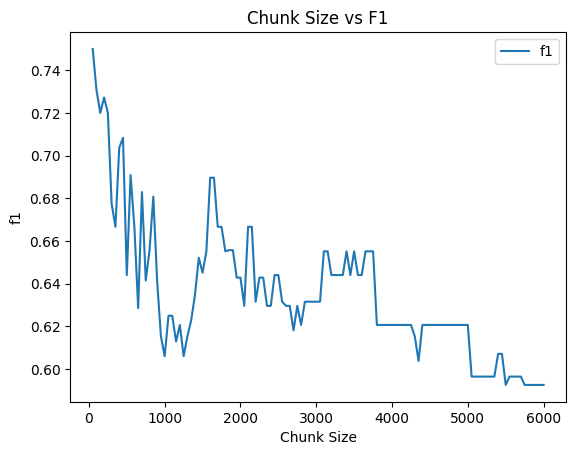

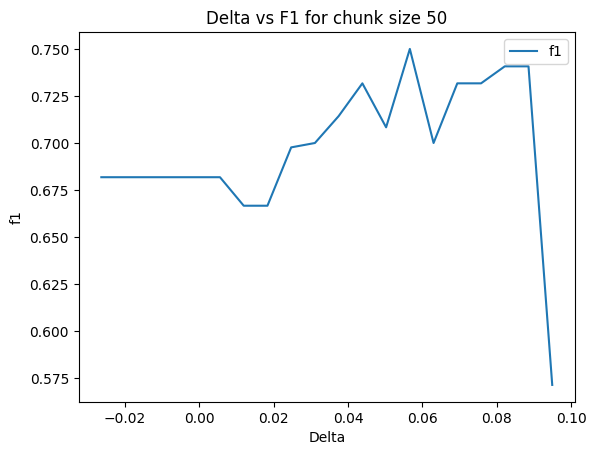

20


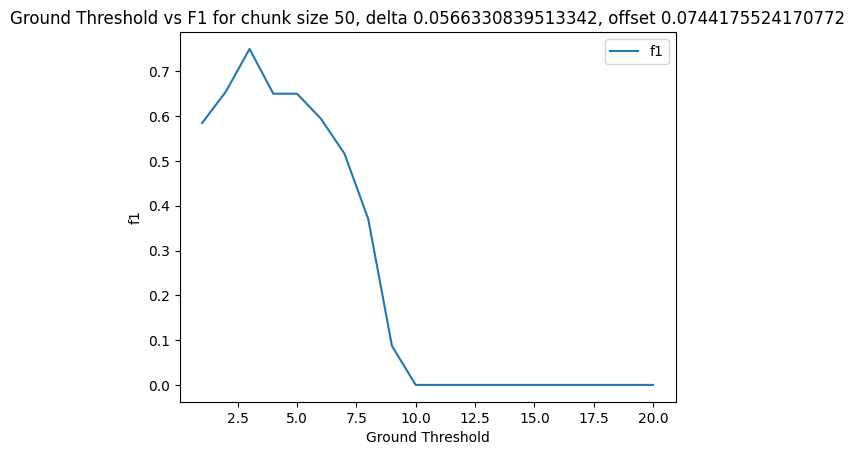

20


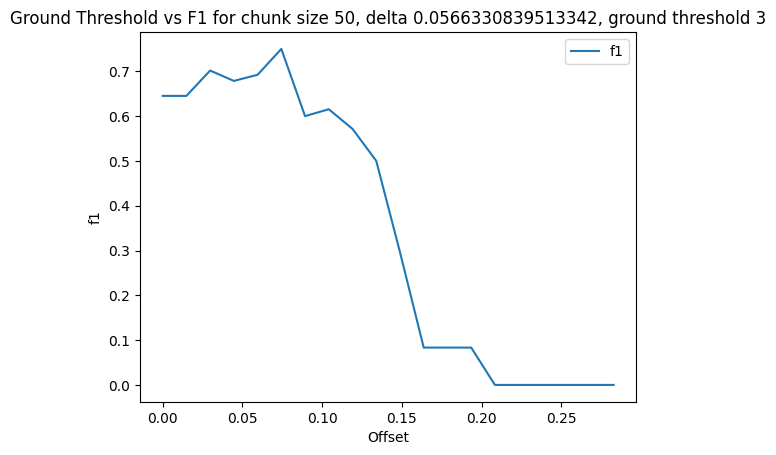

In [30]:
print_chunk_size_vs_f1(df_qwen)
print_delta_vs_f1(df_qwen, chunk_size)
print_ground_threshold_vs_f1(df_qwen, chunk_size, delta, offset)
print_ground_offset_vs_f1(df_qwen, chunk_size, delta, ground_threshold)

In [ ]:
def print_ground_threshold_plot(df_qwen, chunk_size, delta, offset):
    df_qwen_filtered = df_qwen[
        (df_qwen["chunk_size"] == chunk_size)
        & (df_qwen["delta"] == delta)
        & (df_qwen["offset"] == offset)
    ].sort_values("ground_threshold")
    print(len(df_qwen_filtered))
    fig, ax = plt.subplots()
    ax.plot(
        df_qwen_filtered["ground_threshold"],
        df_qwen_filtered["f1"],
        color="C0",
        label="F1",
    )
    acc_col = (
        "validation_accuracy"
        if "validation_accuracy" in df_qwen_filtered.columns
        else "val_test_accuracy"
    )
    ax.plot(
        df_qwen_filtered["ground_threshold"],
        df_qwen_filtered[acc_col],
        color="C1",
        label="validation accuracy",
    )
    ax.set_xlabel("Ground Threshold")
    ax.set_ylabel("score")
    ax.set_title(
        f"Ground threshold vs F1 and validation accuracy "
        f"(chunk_size={chunk_size}, delta={delta}, offset={offset})"
    )
    ax.legend()
    plt.show()


In [ ]:
print